# RKHS Interpolation & Kernel Methods

## Reproducing Kernel Hilbert Spaces

A **Reproducing Kernel Hilbert Space** (RKHS) $\mathcal{H}_k$ is a Hilbert space of functions associated with a symmetric positive-definite **kernel** $k : \mathcal{X} \times \mathcal{X} \to \mathbb{R}$ satisfying the **reproducing property**:
$$f(x) = \langle f, k(\cdot, x) \rangle_{\mathcal{H}_k} \quad \forall f \in \mathcal{H}_k$$

## Kernel Interpolation

Given data points $\{(x_i, f_i)\}_{i=1}^m$, the minimum-norm interpolant in $\mathcal{H}_k$ is:
$$f^*(x) = \sum_{i=1}^m \alpha_i k(x, x_i), \quad \alpha = K^{-1} f$$

where $K_{ij} = k(x_i, x_j)$ is the **Gram matrix** and $f = (f_1, \ldots, f_m)^T$.

This is the **kernel ridge regression** interpolant with zero regularization, and also the **Gaussian process posterior mean** with kernel $k$.

## Common Kernels

| Kernel | Formula $k(x,y)$ | RKHS |
|--------|-----------------|------|
| Gaussian (RBF) | $\exp(-\|x-y\|^2 / (2\sigma^2))$ | $C^\infty$ functions |
| Matérn-$\frac{3}{2}$ | $(1+\sqrt{3}r/\ell)e^{-\sqrt{3}r/\ell}$ | $C^1$ functions |
| Laplacian | $\exp(-r/\sigma)$ | $H^1$ Sobolev |
| Multiquadric | $\sqrt{1 + r^2/\sigma^2}$ | conditionally PD |
| Inverse quadratic | $1/(1 + r^2/\sigma^2)$ | $C^\infty$ |

where $r = \|x - y\|$. The **bandwidth** $\sigma$ controls the smoothness trade-off.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatLogSlider, Dropdown

### Kernel definitions

Each kernel is a function of the pairwise distance $r = \|x - y\|$, parameterized by a bandwidth $\sigma$. We collect them in a dictionary for easy comparison.

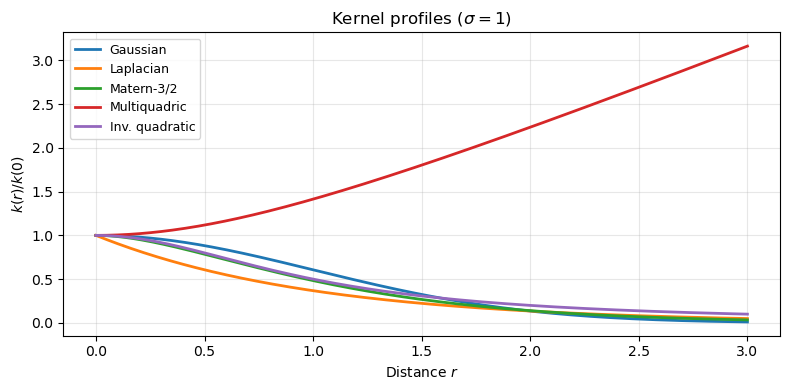

In [2]:
def pairwise_dist(X, Y):
    """Pairwise Euclidean distance matrix between rows of X and Y."""
    X2 = np.sum(X**2, axis=1, keepdims=True)
    Y2 = np.sum(Y**2, axis=1, keepdims=True)
    XY = X @ Y.T
    return np.sqrt(np.maximum(X2 + Y2.T - 2*XY, 0))

KERNELS = {
    'Gaussian':       lambda r, s: np.exp(-r**2 / (2 * s**2)),
    'Laplacian':      lambda r, s: np.exp(-r / s),
    'Matern-3/2':     lambda r, s: (1 + np.sqrt(3)*r/s) * np.exp(-np.sqrt(3)*r/s),
    'Multiquadric':   lambda r, s: np.sqrt(1 + r**2 / s**2),
    'Inv. quadratic': lambda r, s: 1.0 / (1 + r**2 / s**2),
}

def kernel_matrix(X, Y, name, sigma):
    r = pairwise_dist(X, Y)
    return KERNELS[name](r, sigma)

# Visualize kernel profiles
r_plot = np.linspace(0, 3, 300)
fig, ax = plt.subplots(figsize=(8, 4))
for name, k_fn in KERNELS.items():
    k_vals = k_fn(r_plot, 1.0)
    k_vals = k_vals / k_vals[0]  # normalize to 1 at r=0
    ax.plot(r_plot, k_vals, lw=2, label=name)
ax.set_xlabel('Distance $r$'); ax.set_ylabel('$k(r) / k(0)$')
ax.set_title('Kernel profiles ($\\sigma=1$)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('kernels.png', dpi=100, bbox_inches='tight'); plt.show()

### 1D kernel interpolation

Given $m$ scattered 1D data points, the interpolant $f^*(x) = \sum_i \alpha_i k(x, x_i)$ passes exactly through all data values. As $\sigma$ varies, the interpolant ranges from **flat** (large $\sigma$, nearly constant) to **spiky** (small $\sigma$, Dirac-like).

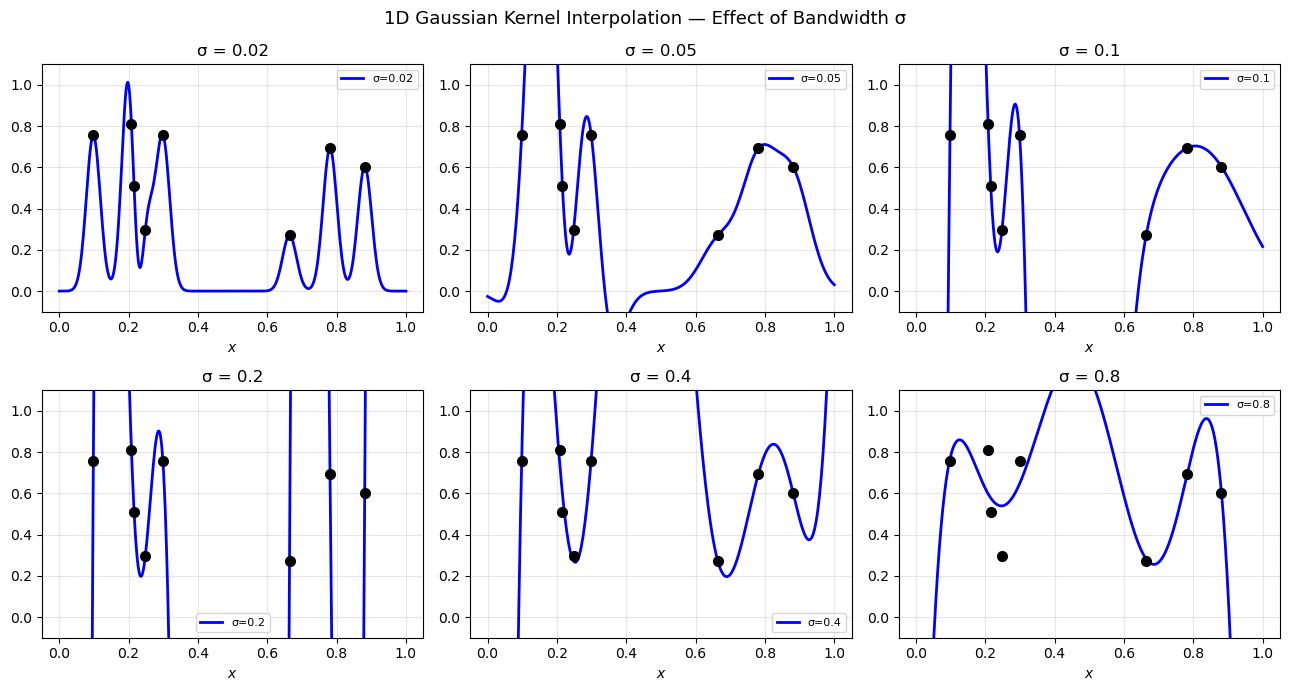

In [3]:
rng = np.random.default_rng(123)
m = 8
x_data = np.sort(rng.uniform(0.05, 0.95, m))[:, None]
f_data = rng.uniform(0.1, 0.9, m)

x_eval = np.linspace(0, 1, 400)[:, None]
sigma_list = [0.02, 0.05, 0.1, 0.2, 0.4, 0.8]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, sigma in zip(axes.ravel(), sigma_list):
    K_dd = kernel_matrix(x_data, x_data, 'Gaussian', sigma)
    alpha = np.linalg.solve(K_dd + 1e-10*np.eye(m), f_data)
    K_ed = kernel_matrix(x_eval, x_data, 'Gaussian', sigma)
    f_pred = K_ed @ alpha
    ax.plot(x_eval, f_pred, 'b-', lw=2, label=f'σ={sigma}')
    ax.plot(x_data, f_data, 'ko', ms=7)
    ax.set_title(f'σ = {sigma}'); ax.set_ylim(-0.1, 1.1)
    ax.set_xlabel('$x$'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('1D Gaussian Kernel Interpolation — Effect of Bandwidth σ', fontsize=13)
plt.tight_layout(); plt.savefig('rkhs_1d.png', dpi=100, bbox_inches='tight'); plt.show()

### Comparing kernels at fixed bandwidth

Different kernels have different smoothness properties. The Gaussian kernel produces $C^\infty$ interpolants; the Laplacian kernel gives $H^1$ Sobolev-class interpolants that can have visible kinks.

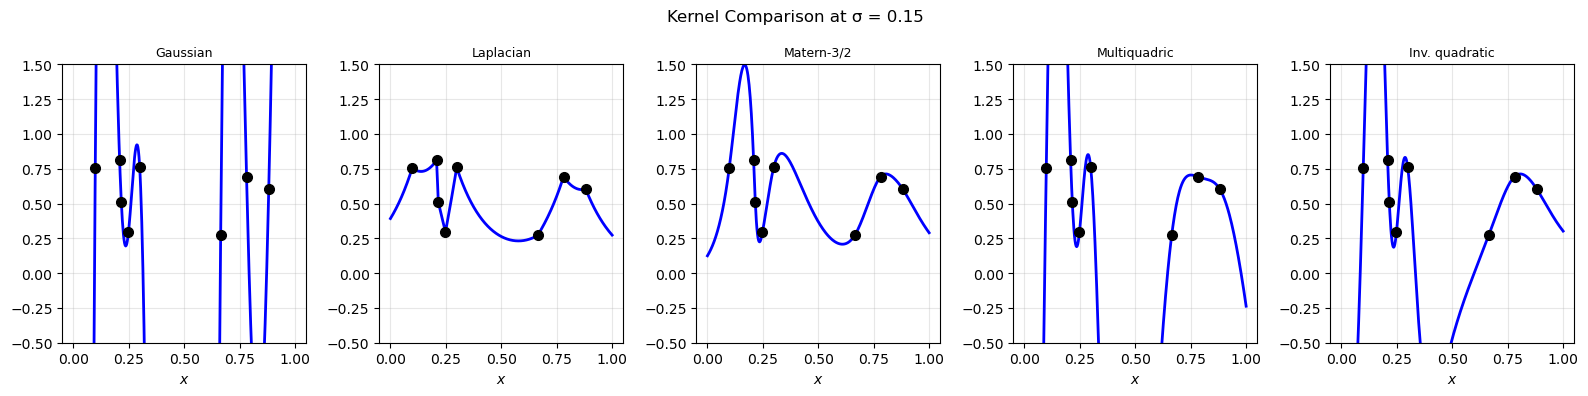

In [4]:
sigma_fixed = 0.15
fig, axes = plt.subplots(1, len(KERNELS), figsize=(16, 4))

for ax, name in zip(axes, KERNELS):
    try:
        K_dd = kernel_matrix(x_data, x_data, name, sigma_fixed)
        alpha = np.linalg.solve(K_dd + 1e-8*np.eye(m), f_data)
        K_ed = kernel_matrix(x_eval, x_data, name, sigma_fixed)
        f_pred = K_ed @ alpha
        ax.plot(x_eval, f_pred, 'b-', lw=2)
        ax.plot(x_data, f_data, 'ko', ms=7)
        ax.set_title(name, fontsize=9)
        ax.set_ylim(-0.5, 1.5); ax.set_xlabel('$x$')
    except np.linalg.LinAlgError:
        ax.set_title(f'{name} (singular)', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Kernel Comparison at σ = {sigma_fixed}', fontsize=12)
plt.tight_layout(); plt.savefig('kernel_compare.png', dpi=100, bbox_inches='tight'); plt.show()

### 2D kernel interpolation

The framework extends immediately to 2D: given scattered points $\{(x_i, y_i, f_i)\}$, we solve $K \alpha = f$ and evaluate $f^*(x) = \sum_i \alpha_i k(x, x_i)$ on a fine grid.

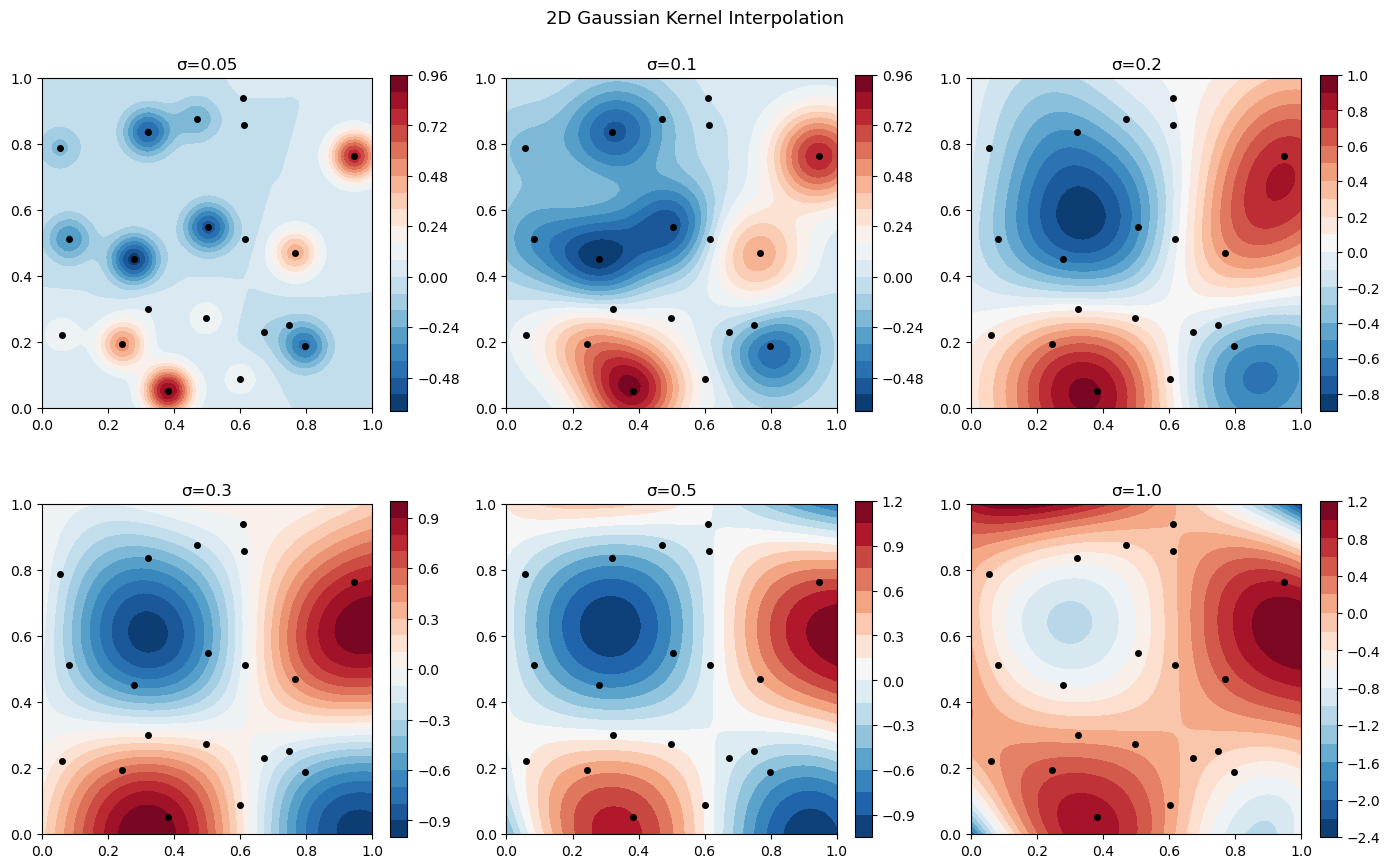

In [5]:
rng2 = np.random.default_rng(7)
m2 = 20
pts = rng2.uniform(0.05, 0.95, (m2, 2))
vals = np.sin(5 * pts[:,0]) * np.cos(5 * pts[:,1])

# Evaluation grid
g = 60
gx = np.linspace(0, 1, g)
Yg, Xg = np.meshgrid(gx, gx)
grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, sigma in zip(axes.ravel(), [0.05, 0.1, 0.2, 0.3, 0.5, 1.0]):
    K_dd = kernel_matrix(pts, pts, 'Gaussian', sigma)
    alpha = np.linalg.solve(K_dd + 1e-8*np.eye(m2), vals)
    K_gd = kernel_matrix(grid_pts, pts, 'Gaussian', sigma)
    f_grid = (K_gd @ alpha).reshape(g, g)

    im = ax.contourf(Xg, Yg, f_grid, levels=20, cmap='RdBu_r')
    ax.plot(pts[:,0], pts[:,1], 'k.', ms=8)
    ax.set_title(f'σ={sigma}'); ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('2D Gaussian Kernel Interpolation', fontsize=13)
plt.tight_layout(); plt.savefig('rkhs_2d.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: kernel and bandwidth selector

In [ ]:
def plot_rkhs(kernel='Gaussian', log_sigma=-1.0):
    sigma = 10**log_sigma
    try:
        K_dd = kernel_matrix(x_data, x_data, kernel, sigma)
        alpha = np.linalg.solve(K_dd + 1e-8*np.eye(m), f_data)
        K_ed = kernel_matrix(x_eval, x_data, kernel, sigma)
        f_pred = K_ed @ alpha
    except Exception:
        return

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x_eval, f_pred, 'b-', lw=2, label='Interpolant')
    ax.plot(x_data, f_data, 'ko', ms=8, label='Data')
    ax.set_title(f'{kernel} kernel, σ={sigma:.4f}')
    ax.legend(); ax.set_ylim(-0.3, 1.3); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

interact(plot_rkhs,
         kernel=Dropdown(options=list(KERNELS.keys()), value='Gaussian'),
         log_sigma=FloatLogSlider(value=-1.0, min=-2, max=0.5, step=0.1,
                                   base=10, description='σ (log)'));

### Snippet

In [6]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(2, 3, figsize=(12, 8))
    for ax, sigma in zip(axes.ravel(), sigma_list):
        K_dd = kernel_matrix(x_data, x_data, 'Gaussian', sigma)
        alpha = np.linalg.solve(K_dd + 1e-10*np.eye(m), f_data)
        K_ed = kernel_matrix(x_eval, x_data, 'Gaussian', sigma)
        f_pred = K_ed @ alpha
        ax.plot(x_eval, f_pred, 'b-', lw=2)
        ax.plot(x_data, f_data, 'ko', ms=7)
        ax.set_title(f'σ = {sigma}'); ax.set_ylim(-0.1, 1.1)
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- RKHS interpolation finds the minimum-norm function passing through all data points — an elegant variational formulation.
- The kernel choice encodes smoothness assumptions; the bandwidth $\sigma$ controls the interpolation scale.
- The solution coefficients $\alpha = K^{-1} f$ are the discrete weights of the **representer theorem**.
- With a nugget (regularization) term, this becomes **Gaussian process regression** (kriging).

## Bibliography

- N. Aronszajn, *Theory of reproducing kernels*, Trans. AMS 68, 1950.
- B. Schölkopf & A. Smola, *Learning with Kernels*, MIT Press, 2002.
- C. E. Rasmussen & C. K. I. Williams, *Gaussian Processes for Machine Learning*, MIT Press, 2006.